# Initalize libraries

## Import libraries

In [1]:
import sys, os
import time
from os.path import join
from os import path
from importlib import reload
from getpass import getuser
from tqdm.auto import tqdm
from multiprocessing import Pool

#data
import numpy as np
import xarray as xr
import h5py
from PIL import Image

# plotting
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm

# Open nexus files
from nexusformat.nexus import *

# pyFAI
import pyFAI
from pyFAI.azimuthalIntegrator import AzimuthalIntegrator
from pyFAI.detectors import Detector

# Self-written libraries
sys.path.append(join(os.getcwd(), "library"))
import helper_functions as helper
import interactive
from interactive import cimshow
import mask_lib

# Gifs
import imageio

plt.rcParams["figure.constrained_layout.use"] = True  # replaces plt.tight_layout

  File "/data/visitors/softimax/20250671/2026021708/shared/2602_venv/lib/python3.11/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/data/visitors/softimax/20250671/2026021708/shared/2602_venv/lib/python3.11/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/data/visitors/softimax/20250671/2026021708/shared/2602_venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/data/visitors/softimax/20250671/2026021708/shared/2602_venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/data/visitors/softimax/20250671/2026021708/shared/2602_venv/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.start()
  File "/data/visitors/softimax/20250671/2026021708/shared/2602_venv/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asynci

In [2]:
# Is there a GPU?
try:
    # Cupy
    import cupy as cp
    import cupyx as cpx

    GPU = True

    print("GPU available")

    # Self-written library
    import CCI_core_cupy as cci
except:
    GPU = False
    import CCI_core as cci

    print("GPU unavailable")

GPU available


In [3]:
# interactive plotting
import ipywidgets

%matplotlib widget

# Auto formatting of cells
#%load_ext jupyter_black

## Experiment specific Functions

In [4]:
facility = "MAXIV" # Options: "SwissFEL", "MAXI"
BEAMTIMEID = 2026021708 # Proposal number
data_fname_prefix = "2602_softimax"
USER = getuser()

# Facility specific loading functions
if facility == "PETRA":
    import PETRA_MaxP04_loading as loading
elif facility == "MAXI":
    import MAXI_loading as loading
elif facility == "SwissFEL":
    from sfdata import SFDataFiles, SFScanInfo, SFProcFile
    import Swiss_FEL_Loading as loading

    # Number or jobs for analysis
    NR_JOBS = 32
elif facility == "MAXIV":
    import MAXI_loading as loading

BASEFOLDER = "/data/visitors/softimax/20250671/%d"%BEAMTIMEID
DATAFOLDER = join(BASEFOLDER,"raw")

print("Raw Datafolder is: %s"%DATAFOLDER)

# Load dictionary for keys etc
mnemonics = loading.load_mnemonics()

Raw Datafolder is: /data/visitors/softimax/20250671/2026021708/raw


### Loading data

In [5]:
def generate_filename(scan_nr: int):
    """
    Generates filename of the given scan id

    Parameter
    =========
    scan_nr : number identifier (id) of the given scan

    Output
    ======
    filename : str
        full generated filename
    ======
    author: ck 2025
    """
    return join(DATAFOLDER, f"{data_fname_prefix}_{scan_nr:04d}.h5")

def load_key(scan_id, key):
    """
    Load any kind of data specified by key (path)
    
    Parameter
    =========
    scan_id : int
        experimental identifier of scan
    key : str
        key path of nexus file tree to relevant data field
   
    Output
    ======
    data : dict
        data dictionaray on single key
    ======
    author: ck 2024
    """
    #Generate filename from scan_id
    fname = generate_filename(scan_id)
    
    # load data with basic loading function
    data = loading.load_key(fname, key)
    
    return data

def load_data(scan_id, keypath=mnemonics["measurement"], keys=None):
    """
    Load data of all specified keys from keypath

    Parameter
    =========
    scan_id : int
        experimental identifier of scan
    keypath : str
        path of nexus file tree to relevant data field
    keys : str or list of strings
        keys to load from keypath

    Output
    ======
    data : dict
        data dictionary of keys
    ======
    author: ck 2024
    """

    # Generate filename from scan_id
    fname = generate_filename(scan_id)

    # load data with basic loading function
    data = loading.load_data(fname, keypath, keys=keys)

    return data


## Loading images

In [6]:
def get_filepath(tiffname, camera_type = "cmos"):
    """Return raw data path from save file path."""
    head, tifffile = path.split(tiffname)
    head, scandir = path.split(head)
    return path.join(DATAFOLDER, camera_type, scandir, tifffile)

def load_tiff(tifffile):
    """load single tiff image into np array"""
    return np.array(Image.open(tifffile))

def load_tiff_list(filelist, processes=None):
    """Multiprocessing loading of image files"""
    with Pool(processes=processes) as pool:
        frames = pool.map(load_tiff, filelist)
    return np.stack(frames)

def load_cmos(scanid, file_indices = None):
    # Loads all single frames
    fname = generate_filename(scanid)
    cmos_filelist = load_key(scanid,mnemonics["cmos"])
    cmos_filelist = [get_filepath(b.decode(),camera_type = "cmos") for b in cmos_filelist]

    if file_indices is not None:
        cmos_filelist = [cmos_filelist[index] for index in file_indices]

    print("Loading %d single frames"%len(cmos_filelist))
    return load_tiff_list(cmos_filelist)

In [7]:
def load_images(im_id: int, file_indices=None, camera_type: str = "ccd"):
    """
    Load images corresponding to a given experimental image ID.

    Parameters
    ----------
    im_id : int
        Experimental identifier of the image scan.
    file_indices : array-like or None, optional
        Indices of frames to select from the image stack.
        If None, all frames are returned.
    camera_type : {"ccd", "cmos"}, optional
        Camera type used for acquisition.

    Returns
    -------
    images : np.ndarray
        Image stack with shape (n_frames, height, width).

    Raises
    ------
    ValueError
        If an unsupported camera_type is specified.
    ======
    author: ck 2024
    """

    if camera_type == "ccd":
        meta = load_data(im_id)

        try:
            raw_name = meta["ccd"][0]
        except (KeyError, IndexError) as exc:
            raise ValueError(f"No CCD data found for im_id={im_id}") from exc

        spe_path = (
            f"{BASEFOLDER}/raw/ccd/"
            f"{str(raw_name).split('//')[1].split('.spe')[0]}-raw.spe"
        )

        frames = imageio.mimread(spe_path, memtest="5000MB")
        images = np.squeeze(np.asarray(frames))

        if file_indices is not None:
            images = images[file_indices]

        images = np.stack(images)

    elif camera_type == "cmos":
        images = load_cmos(im_id, file_indices)

    else:
        raise ValueError(
            f"Unsupported camera_type '{camera_type}'. "
            "Valid options are 'ccd' and 'cmos'."
        )

    return images


### Loading image procedure

In [8]:
# Full image loading procedure
def load_processing(im_id, file_indices = None, binning = 1, crop = None):
    """
    Loads images, averaging of two individual images (scans in tango consist of two images),
    padding to square shape, Additional cropping (optional)
    """

    # Load data
    images = load_images(im_id, file_indices = file_indices)

    # Optional cropping
    if crop is not None:
        images = images[..., :crop, :crop]

    # Binning
    if binning > 1:
        images = helper.binning(images, binning)

    # Average over all images
    if images.ndim == 4:
        image = np.mean(images, axis=(0, 1))
    elif images.ndim == 3:
        image = np.mean(images, axis=(0))
    elif images.ndim == 2:
        image = images.copy()
    images = np.stack(images)
    
    return image, images

## Other

In [9]:
def combine_scans(array):
    try: 
        array = np.stack(array)
    except:
        array = np.concatenate(array)
    return np.squeeze(array)

In [10]:
def save_gif(output_path, image_path_list, fps=3 ):
    writer = imageio.get_writer(output_path, format="GIF-PIL", fps=fps)
    for im in tqdm(image_path_list):
        writer.append_data(imageio.imread(im))
    writer.close()

# Experimental Details

In [11]:
# Dict with most basic experimental parameter
experimental_setup = {
    "ccd_dist": 0.095,  # ccd to sample distance
    "px_size": 11e-6,  # CMOS: 11 um, CCD: 13.5 um
    "binning": 1,  # Camera binning
    "oversaturation": 2**16,  # Pixel saturation threshold
}

# Setup for azimuthal integrator
detector = Detector(
    experimental_setup["binning"] * experimental_setup["px_size"],
    experimental_setup["binning"] * experimental_setup["px_size"],
)

# General saving folder
folder_general = helper.create_folder(join(BASEFOLDER, "process"))
print("Output Folder: %s" % folder_general)

Output Folder: /data/visitors/softimax/20250671/2026021708/process


# Load images


In [211]:
# Specify image ids in iterable like list or array
im_ids = np.arange(2019,2070+1)
dark_ids = 2071*np.ones(len(im_ids),dtype=int) #iterable; one needs to be assigned for each image

# Which data from nexus files to load? (e.g. "energy","srotz", ...)
key = "energy"

# Sort data according to scan axis?
sort = False

## Normalize?
normalization = False
norm_key = "maxibeckhoff1adc2_rmean"

# Load single dark if all dark_ids are the same
if np.all(dark_ids):
    print("Loading single dark")
    dark, _ = load_processing(dark_ids[0], file_indices = None, crop=None)

# Load data
images, scan_axis, norm = [], [], []
for i, im_id in enumerate(tqdm(im_ids)):
    # load images
    timage, _ = load_processing(im_id)

    ## Load and subtract dark images
    if (np.all(dark_ids) is False):
        dark, _ = load_processing(dark_ids[i], file_indices = None, crop=None)
    elif dark_ids is None:
        dark = np.zeros(timage.shape)
    timage = timage - dark
    
    # Append to data variable
    images.append(timage)

    # Load scan axis or single image data
    scan_axis.append(load_key(im_id,mnemonics[key]))
    
    # Load normalization
    if normalization is True:
        norm.append(load_key(im_id,mnemonics[key]))
    else:
        norm.append(np.ones(timage.shape[0]))

    # Get one lambda value
    energies, energy_lambda = [], []
    energies.append(load_key(im_id, mnemonics["energy"]))
    energy_lambda.append(helper.photon_energy_wavelength(load_key(im_id, mnemonics["energy"])))

Loading single dark


  0%|          | 0/52 [00:00<?, ?it/s]

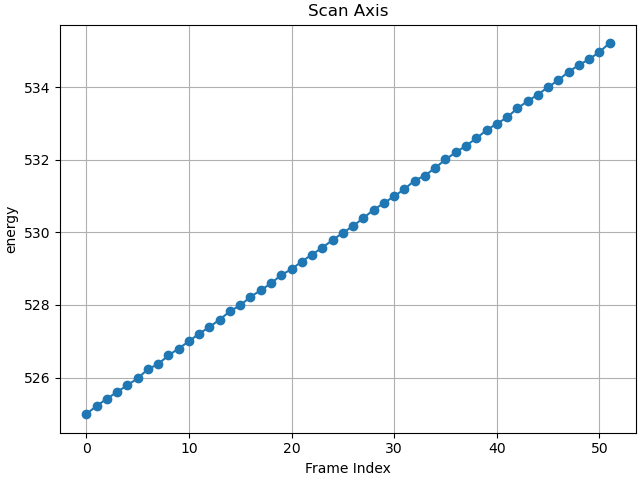

In [212]:
# Combine all scans into single array
images = combine_scans(images)
scan_axis = combine_scans(scan_axis)
norm = combine_scans(norm)

# Plot scan axis
fig, ax = plt.subplots()
ax.plot(scan_axis, "o-")
ax.set_title("Scan Axis")
ax.set_ylabel(key)
ax.set_xlabel("Frame Index")
ax.grid()

interactive(children=(FloatRangeSlider(value=(-8.830973523421585, 204.9488065173116), description='contrast', …

interactive(children=(IntSlider(value=0, description='nr', max=51), Output()), _dom_classes=('widget-interact'…

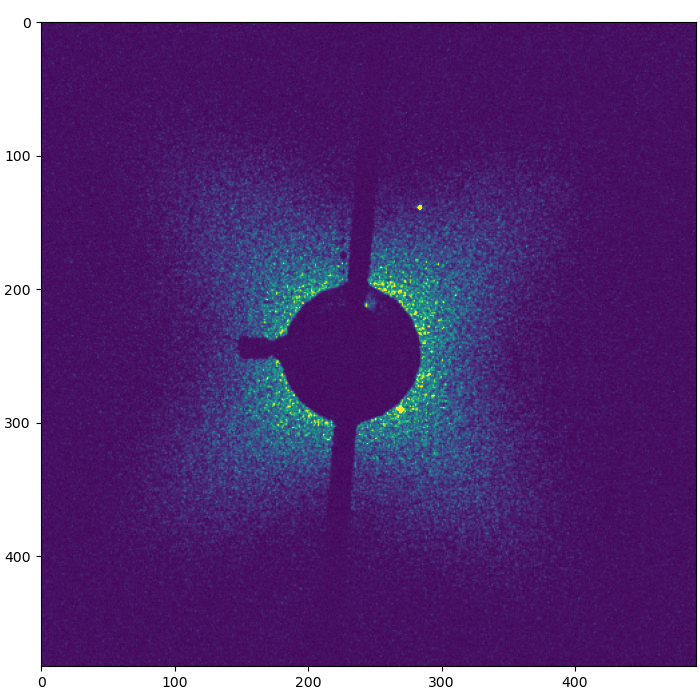

In [213]:
# Assign to xarray
# Setup xarray for images
data = xr.Dataset()
data[key] = xr.DataArray(scan_axis, dims=["index"])
data["ids"] = xr.DataArray(im_ids, dims=["index"])
data["images"] = xr.DataArray(images, dims=["index", "y", "x"])

# Subtract drifting offset of detector
sel = data.y < 25
data["offset"] = data["images"].where(sel).mean(["y","x"])
data["images"] = data["images"] - data["offset"]

data["image"] = data["images"].mean("index")
image = data["image"].values

# Sort ascending key
if sort is True:
    data = data.sortby(key)

# Assign im_id as attribute
data = data.assign_attrs({"im_ids": im_ids})

# Slideshow viewer
fig, ax = cimshow(data["images"])

interactive(children=(FloatRangeSlider(value=(-8.830973523421585, 204.9488065173116), description='contrast', …

interactive(children=(IntSlider(value=0, description='nr', max=51), Output()), _dom_classes=('widget-interact'…

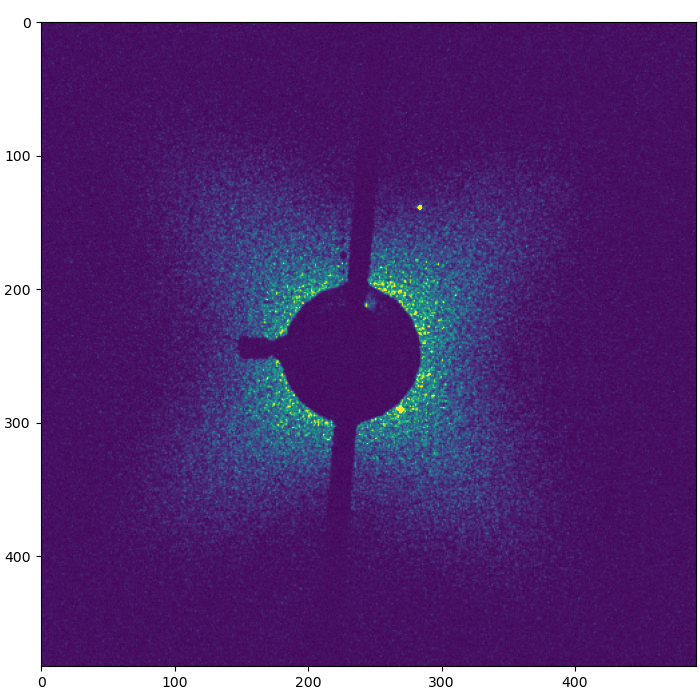

In [218]:
# ROI for charge background intensity reference
fig, ax = cimshow(data["images"])

In [219]:
x1, x2 = ax.get_xlim()
y2, y1 = ax.get_ylim()
roi = np.array([y1, y2, x1, x2]).astype(int)  # ystart, ystop, xstart, xstop
roi_s = np.s_[roi[0] : roi[1], roi[2] : roi[3]]

In [220]:
ref_image = data["images"][0].values.copy()
diff = np.zeros_like(data["images"].values)

folder_gif = helper.create_folder(join(folder_general, "%d-%d" % (im_ids[0],im_ids[-1])))
frame_paths = []
for i, im in enumerate(data["images"].values):
    factor, offset = cci.dyn_factor(
    im[roi_s],
    ref_image[roi_s],
    method="correlation",
    verbose=True,
    plot=False)

    diff[i] = im/factor - ref_image

    # Plot image
    plt.ioff()
    fig, ax = plt.subplots()
    ax.set_title(f"ImId: {data.ids.values[i]:03d} @ {key}: {data[key].values[i]:.2f} ")
    vmin, vmax = np.percentile(diff[i],(1,99))
    ax.imshow(diff[i], vmin=vmin,vmax=vmax)
    
    # Save image
    fname = "SAXS_ImId_%04d_%04d_%03d_%s.png" % (im_ids[0], im_ids[-1], i, USER)

    # Save
    fname = path.join(folder_gif, fname)
    frame_paths.append(fname)
    plt.savefig(fname)

# Create gif
output_gif = f"SAXS_{im_ids[0]}-{im_ids[-1]}.gif"
save_gif(join(folder_general,output_gif), frame_paths, fps=2)
plt.ion()

# Add also to xarray
data["diffs"] = xr.DataArray(diff,dims=["index","y","x"])
#sel = data.y < 25
#data["offset_diff"] = data["diffs"].where(sel).mean(["y","x"])
#data["diffs"] = data["diffs"] - data["offset_diff"]

/data/visitors/softimax/20250671/2026021708/shared/ck/FTH-Phase_Retrieval/library/CCI_core_cupy.py:321: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = scipy.optimize.curve_fit(func, xdata, ydata)


Linear Fit: 1.0000*x + -0.0000
Linear Fit: 0.9737*x + 0.4324
Linear Fit: 0.9488*x + 0.2626
Linear Fit: 1.0060*x + -2.0476
Linear Fit: 0.9858*x + -1.0929
Linear Fit: 0.9983*x + -2.0032
Linear Fit: 1.0084*x + -2.6849
Linear Fit: 1.0115*x + -3.7799
Linear Fit: 1.0036*x + -4.5641
Linear Fit: 0.9999*x + -4.6112
Linear Fit: 0.9721*x + -4.6628
Linear Fit: 0.9582*x + -5.7908
Linear Fit: 0.9346*x + -6.2890
Linear Fit: 0.8613*x + -5.8131
Linear Fit: 0.8532*x + -7.1642
Linear Fit: 0.8582*x + -8.5712
Linear Fit: 0.8494*x + -8.3747
Linear Fit: 0.8972*x + -11.1708
Linear Fit: 0.8243*x + -9.2548
Linear Fit: 0.8136*x + -6.9805
Linear Fit: 0.8208*x + -0.3385
Linear Fit: 0.7616*x + 14.0340
Linear Fit: 0.7630*x + 23.3776
Linear Fit: 0.7569*x + 28.1225
Linear Fit: 0.7806*x + 30.3433
Linear Fit: 0.7573*x + 34.1706
Linear Fit: 0.7868*x + 36.1102
Linear Fit: 0.7797*x + 38.5690
Linear Fit: 0.7734*x + 37.2920
Linear Fit: 0.7622*x + 26.0889
Linear Fit: 0.6758*x + 10.2146
Linear Fit: 0.6166*x + -7.3463
Linear Fi

  0%|          | 0/52 [00:00<?, ?it/s]

/tmp/ipykernel_2291356/144149053.py:4: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  writer.append_data(imageio.imread(im))


interactive(children=(FloatRangeSlider(value=(-128.46047208726634, 170.82565873652968), description='contrast'…

interactive(children=(IntSlider(value=0, description='nr', max=51), Output()), _dom_classes=('widget-interact'…

(<Figure size 700x700 with 1 Axes>, <Axes: >)

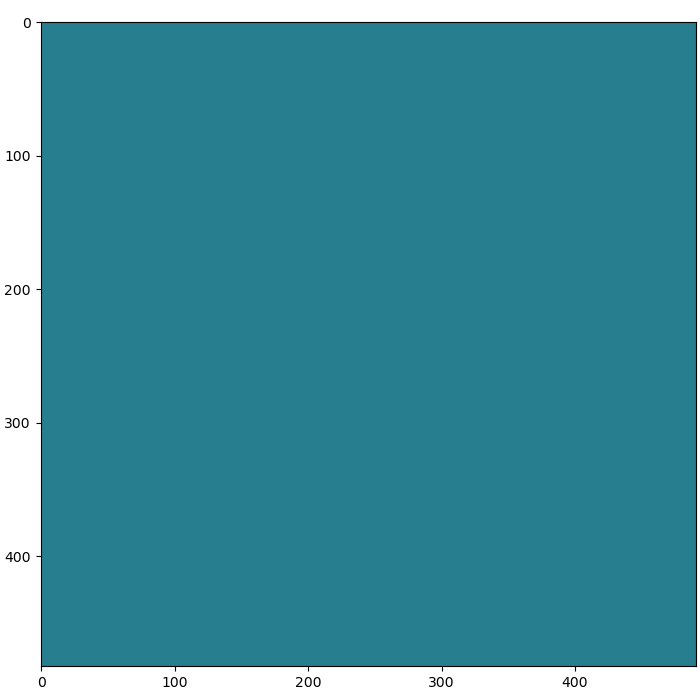

In [221]:
cimshow(data["diffs"])

# Draw beamstop mask

interactive(children=(FloatRangeSlider(value=(-0.6400006896551678, 157.84827931034056), description='contrast'…

Click on the figure to create a polygon corner.
Click `Add mask` to store coordinates and apply mask.
Press the 'esc' key to reset the polygon for new drawing.

Try holding the 'shift' key to move all of the vertices.
Try holding the 'ctrl' key to move a single vertex.
Button `Delete mask` deletes the masks recursively.


Button(button_style='warning', description='Add mask', layout=Layout(height='auto', width='100px'), style=Butt…

Button(description='Delete mask', layout=Layout(height='auto', width='100px'), style=ButtonStyle())

Output()

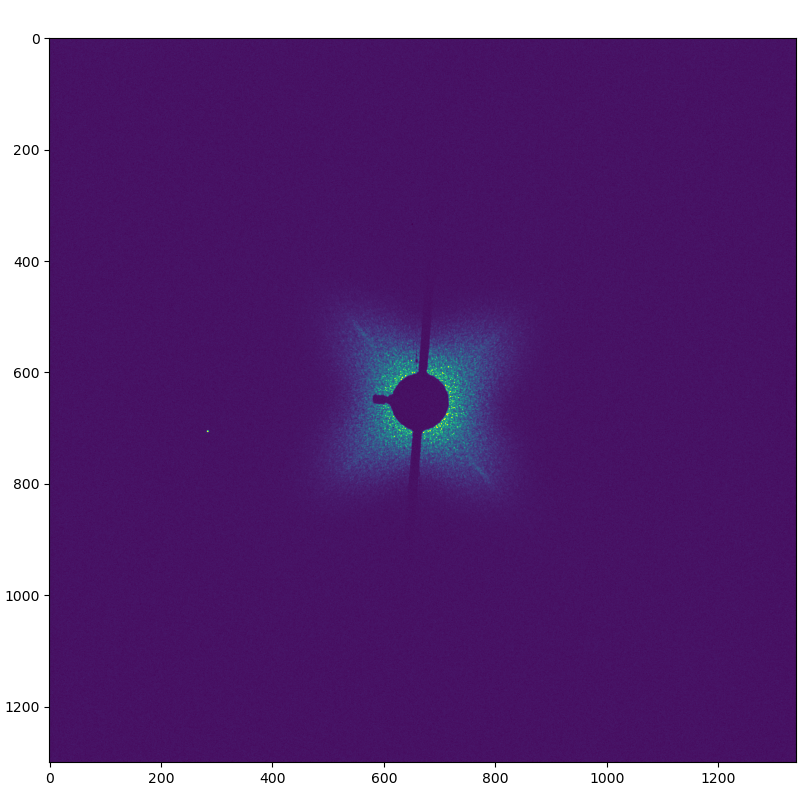

In [94]:
poly_mask = interactive.draw_polygon_mask(image)

Copy these coordinates into the 'load_poly_coordinates()' function:
[]


Text(0.5, 1.0, '1 - mask_draw')

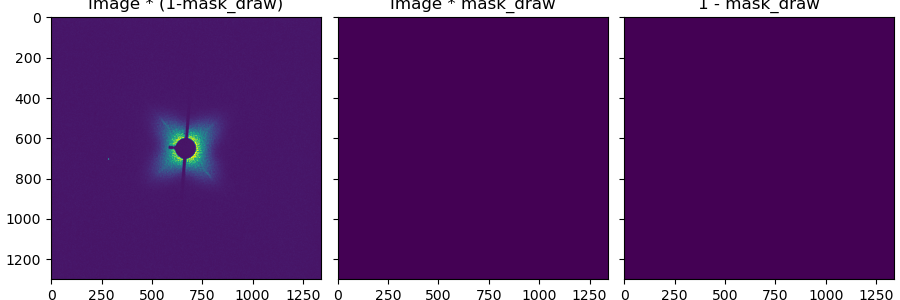

In [95]:
# Take poly coordinates and mask from widget
p_coord = poly_mask.get_vertice_coordinates()
mask_draw = poly_mask.full_mask.astype(int)

print("Copy these coordinates into the 'load_poly_coordinates()' function:")
print(p_coord)

# Plot image with beamstop and valid pixel mask
fig, ax = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(9, 3))
tmp = image * (1 - mask_draw)
mi, ma = np.percentile(tmp[tmp != 0], [0.1, 99.9])
ax[0].imshow(image * (1 - mask_draw), cmap="viridis", vmin=mi, vmax=ma)
ax[0].set_title("Image * (1-mask_draw)")

mi, ma = np.percentile(image * mask_draw, [0.1, 99.9])
ax[1].imshow(image * mask_draw, vmin=mi, vmax=ma)
ax[1].set_title("Image * mask_draw")

ax[2].imshow(1 - mask_draw)
ax[2].set_title("1 - mask_draw")

In [96]:
def load_poly_coordinates():
    """
    Dictionary that stores polygon corner coordinates of all drawn masks
    Example: How to add masks with name "test":
    mask_coordinates["test"] = copy coordinates from above
    """
    mask_coordinates = dict()
    mask_coordinates["bs_fixed"] = [[(988.2, 990.2), (984.2, 994.4), (981.3, 998.7), (977.6, 1005.4), (975.0, 1012.4), (974.1, 1019.8), (973.8, 1027.4), (974.8, 1036.8), (978.6, 1045.5), (985.1, 1055.4), (994.3, 1063.7), (1008.0, 1070.0), (1017.1, 1071.3), (1030.1, 1070.7), (1040.0, 1068.9), (1046.8, 1063.9), (1055.5, 1056.5), (1061.6, 1049.8), (1066.1, 1040.2), (1068.3, 1026.0), (1067.6, 1014.4), (1063.3, 1001.6), (1054.6, 989.9), (1039.8, 980.1), (1026.3, 977.4), (1010.9, 977.6), (1000.5, 981.2), (992.5, 986.5)], [(998.8, 983.3), (982.8, 952.5), (972.0, 934.3), (972.7, 930.4), (971.3, 925.6), (967.4, 923.3), (964.2, 917.6), (964.1, 905.3), (957.5, 902.2), (954.5, 898.7), (954.5, 892.1), (948.6, 886.9), (946.5, 885.6), (946.5, 879.6), (943.0, 875.5), (920.2, 835.4), (883.5, 766.0), (830.6, 666.8), (780.8, 573.0), (742.5, 502.3), (738.2, 505.0), (777.5, 577.0), (787.8, 595.5), (825.3, 667.0), (849.8, 713.1), (878.5, 766.6), (892.3, 792.3), (917.7, 840.1), (935.9, 876.1), (935.4, 878.6), (934.6, 884.1), (937.0, 886.7), (941.8, 886.0), (943.5, 888.9), (941.9, 893.4), (943.5, 898.5), (947.2, 899.9), (948.6, 900.9), (951.2, 905.4), (950.8, 909.8), (951.2, 915.5), (955.0, 918.6), (957.9, 919.3), (962.7, 925.8), (962.7, 929.6), (963.2, 935.0), (968.1, 936.2), (979.4, 959.8), (995.1, 988.5)], [(1036.9, 1066.7), (1040.3, 1073.7), (1040.1, 1077.6), (1041.0, 1080.0), (1044.9, 1081.2), (1058.7, 1107.6), (1058.7, 1112.4), (1062.8, 1115.3), (1067.9, 1125.5), (1079.7, 1146.5), (1080.2, 1151.6), (1082.4, 1153.8), (1086.0, 1157.7), (1086.8, 1163.5), (1089.7, 1165.2), (1092.3, 1171.5), (1094.0, 1176.3), (1096.4, 1178.0), (1100.6, 1187.2), (1102.7, 1193.0), (1106.4, 1198.3), (1116.5, 1216.7), (1117.0, 1223.0), (1123.3, 1230.3), (1128.0, 1238.8), (1128.0, 1243.6), (1133.3, 1246.0), (1137.4, 1255.8), (1143.0, 1266.0), (1153.3, 1284.7), (1153.3, 1288.6), (1154.3, 1291.7), (1158.8, 1295.1), (1161.3, 1300.8), (1184.9, 1344.8), (1209.4, 1390.3), (1225.3, 1420.6), (1226.0, 1425.9), (1241.2, 1447.6), (1260.1, 1485.8), (1313.3, 1586.8), (1337.1, 1632.3), (1342.1, 1630.4), (1289.7, 1528.6), (1246.2, 1445.2), (1234.1, 1426.0), (1233.9, 1420.2), (1166.8, 1296.7), (1167.3, 1290.0), (1162.7, 1286.1), (1158.2, 1280.8), (1137.2, 1243.4), (1137.6, 1237.9), (1133.8, 1235.4), (1125.6, 1221.2), (1125.6, 1215.0), (1121.8, 1212.8), (1104.4, 1180.1), (1098.3, 1169.5), (1094.4, 1163.5), (1094.9, 1160.6), (1091.3, 1155.8), (1067.9, 1112.9), (1067.9, 1108.4), (1064.8, 1105.0), (1050.1, 1078.8), (1050.1, 1074.4), (1045.6, 1068.9), (1041.5, 1064.6)]]
    mask_coordinates["cmos_damage"] = [[(1117.3, 1126.5), (1106.3, 1135.0), (1105.8, 1144.3), (1111.1, 1150.8), (1122.4, 1153.6), (1127.2, 1148.0), (1126.9, 1135.6), (1122.1, 1129.4)]]
    mask_coordinates["bs_large"] = [[(700.0, 30.2), (704.0, -5.6), (728.7, -4.3), (713.9, 222.8), (683.1, 593.1), (685.6, 599.8), (718.6, 629.5), (721.1, 648.9), (717.7, 670.8), (705.6, 692.1), (684.3, 706.9), (672.3, 709.4), (667.1, 768.3), (659.7, 860.9), (642.1, 1098.8), (626.0, 1311.4), (593.3, 1309.6), (615.8, 1109.0), (638.7, 817.1), (645.8, 708.2), (625.1, 694.6), (614.6, 681.9), (609.4, 668.7), (606.9, 659.4), (592.4, 660.9), (575.7, 659.7), (573.6, 636.6), (592.7, 637.5), (610.3, 637.2), (618.3, 623.0), (636.8, 606.0), (655.3, 597.4), (671.1, 437.8), (685.9, 209.8)]]
    return mask_coordinates

In [228]:
image.shape

(483, 491)

In [229]:
mask_draw.shape

(67, 86)

interactive(children=(FloatRangeSlider(value=(-5.942934482218392, 114.7021424408599), description='contrast', …

interactive(children=(FloatSlider(value=0.0, description='shift_ver', layout=Layout(width='350px'), max=122.75…

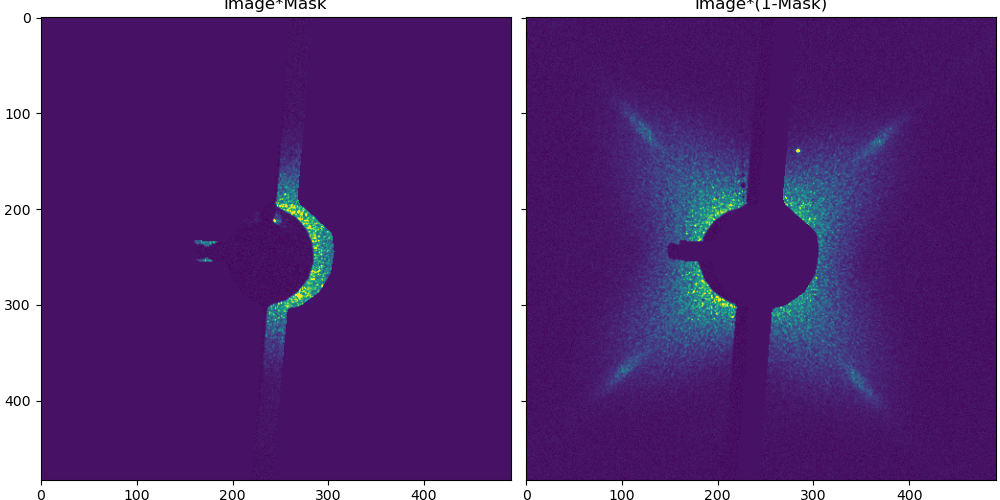

In [231]:
# Which drawn masks do you want to load? Use can combine multiple masks, e.g., ["bs_left_part", "bs_bot_part", "bs_top_part"]
polygon_names = ["bs_large"]
mask_draw = mask_lib.load_poly_masks(
    experimental_setup["binning"] * np.array((1300,1300)),
    load_poly_coordinates(),
    polygon_names,
)
mask_draw = mask_draw[405:888,416:907]

# optional binning
mask_draw = helper.binning(mask_draw,experimental_setup["binning"])

# Use widget to shift and expand or shrink the mask
ss_mask = interactive.Shift_Scale_Mask(image, mask_draw, shift=[0,1], scale=-1)

/tmp/ipykernel_2291356/3510358357.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


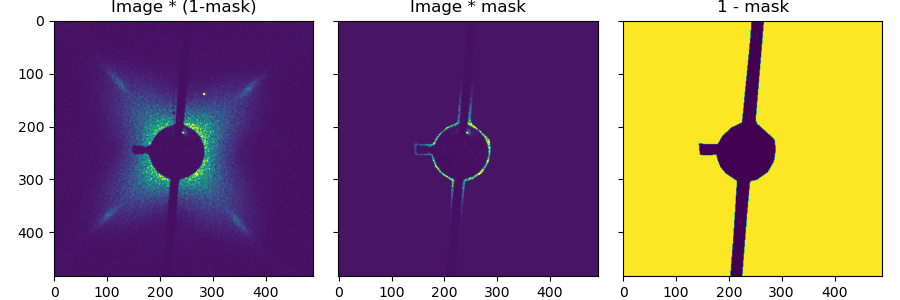

In [232]:
# Take mask, shift and scaling from widget
mask, mask_shift, mask_scale = ss_mask.get_mask()

# Add to xarray
data["mask"] = xr.DataArray(mask, dims=["y", "x"])

# Plot image with beamstop and valid pixel mask
fig, ax = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(9, 3))
mi, ma = np.percentile(image, [0.1, 99.9])
ax[0].imshow(image, cmap="viridis", vmin=mi, vmax=ma)
ax[0].set_title("Image * (1-mask)")

mi, ma = np.percentile(image * mask, [0.1, 99.9])
ax[1].imshow(image * mask, vmin=mi, vmax=ma)
ax[1].set_title("Image * mask")

ax[2].imshow(1 - mask)
ax[2].set_title("1 - mask")
plt.tight_layout()

## Basic widget to find center

Try to **align** the circles to the **center of the scattering pattern**. Care! Position of beamstop might be misleading and not represent the actual center of the hologram. 

interactive(children=(FloatRangeSlider(value=(-8.830973523421585, 204.9488065173116), description='contrast', …

interactive(children=(IntSlider(value=0, description='nr', max=51), Output()), _dom_classes=('widget-interact'…

interactive(children=(IntText(value=654, description='c0 (vert)', step=0), IntText(value=668, description='c1 …

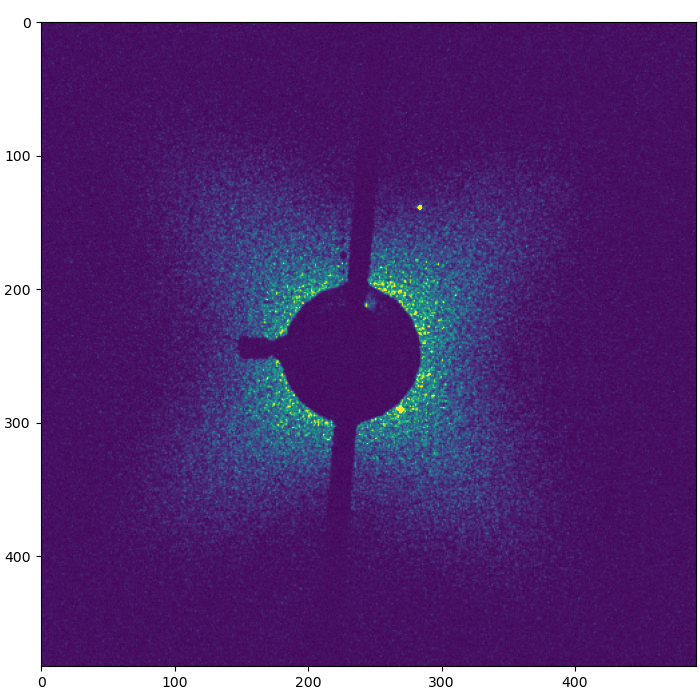

In [222]:
# Set center position via widget
c0, c1 = 654, 668 # initial values
ic = interactive.InteractiveCenter(data["images"], c0=c0, c1=c1)

In [223]:
# Get center positions
center = [ic.c0, ic.c1]
print(f"Center:", center)

Center: [250, 233]


## Azimuthal integrator widget for finetuning
If scattering pattern is radial symmetric, move center position until scattering ring is a line after transformation in polar coordinates

In [101]:
# Setup azimuthal integrator for virtual geometry
ai = AzimuthalIntegrator(
    dist=experimental_setup["ccd_dist"],
    detector=detector,
    wavelength=energy_lambda[0],
    poni1=center[0]
    * experimental_setup["px_size"]
    * experimental_setup["binning"],  # y (vertical)
    poni2=center[1]
    * experimental_setup["px_size"]
    * experimental_setup["binning"],  # x (horizontal)
)

Text(0.5, 1.0, 'Azimuthal integration')

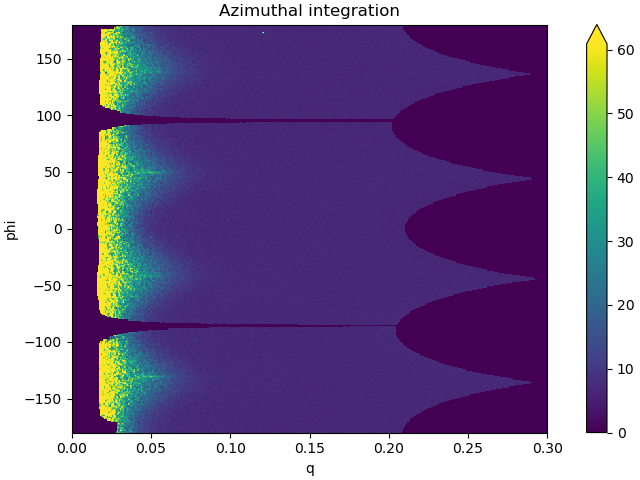

In [102]:
# Calc azimuthal integration
I_t, q_t, phi_t = ai.integrate2d(
    image,
    700,
    radial_range=(0.0, .3),
    unit="q_nm^-1",
    correctSolidAngle=True,
    dummy=np.nan,
    mask=mask,
    method = "BBox"
)
az2d = xr.DataArray(I_t, dims=("phi", "q"), coords={"q": q_t, "phi": phi_t})

# Plot
fig, ax = plt.subplots()
mi, ma = np.nanpercentile(I_t, [1, 98])
az2d.plot.imshow(ax=ax, vmin=mi, vmax=ma)
plt.title(f"Azimuthal integration")

# Azimuthal integration for all images

In [235]:
# Update center of azimuthal integrator
ai = AzimuthalIntegrator(
    dist=experimental_setup["ccd_dist"],
    detector=detector,
    wavelength=energy_lambda[0],
    poni1=center[0]
    * experimental_setup["px_size"]
    * experimental_setup["binning"],  # y (vertical)
    poni2=center[1]
    * experimental_setup["px_size"]
    * experimental_setup["binning"],  # x (horizontal)
)

In [236]:
# Do 2d Azimuthal integration of all images and append them to list
list_q, list_i2d, list_i2d_diff = [], [], []

timages = data["images"].values
tdiffs = data["diffs"].values

for i, _ in enumerate(tqdm(timages,desc="SAXS images")):
    # Adapt azimuthal integrator if scan is an energy scan
    if key == "energy":
        ai.wavelength = helper.photon_energy_wavelength(data["energy"][i].values)

    # Calc ai for normal images
    i2d, q, chi = ai.integrate2d(
        timages[i],
        500,
        90,
        radial_range=(0.0, 0.15),
        unit="q_nm^-1",
        correctSolidAngle=True,
        dummy=np.nan,
        mask=mask,
        method = "BBox"
    )
    list_i2d.append(i2d)
    list_q.append(q)

    # Calc ai for diff images
    i2d, _, _ = ai.integrate2d(
        tdiffs[i],
        500,
        90,
        radial_range=(0.0, 0.15),
        unit="q_nm^-1",
        correctSolidAngle=True,
        dummy=np.nan,
        mask=mask,
        method = "BBox"
    )
    list_i2d_diff.append(i2d)

# Add to xarrays
data["q"] = q
data["chi"] = chi
data["i2d"] = xr.DataArray(list_i2d, dims=["index", "chi", "q"])
data["i2d_diff"] = xr.DataArray(list_i2d_diff, dims=["index", "chi", "q"])

SAXS images:   0%|          | 0/52 [00:00<?, ?it/s]

## Select relevant chi-range

interactive(children=(FloatRangeSlider(value=(-92.87010001373291, 125.23678422546485), description='contrast',…

interactive(children=(IntSlider(value=0, description='nr', max=51), Output()), _dom_classes=('widget-interact'…

(<Figure size 700x700 with 1 Axes>, <Axes: >)

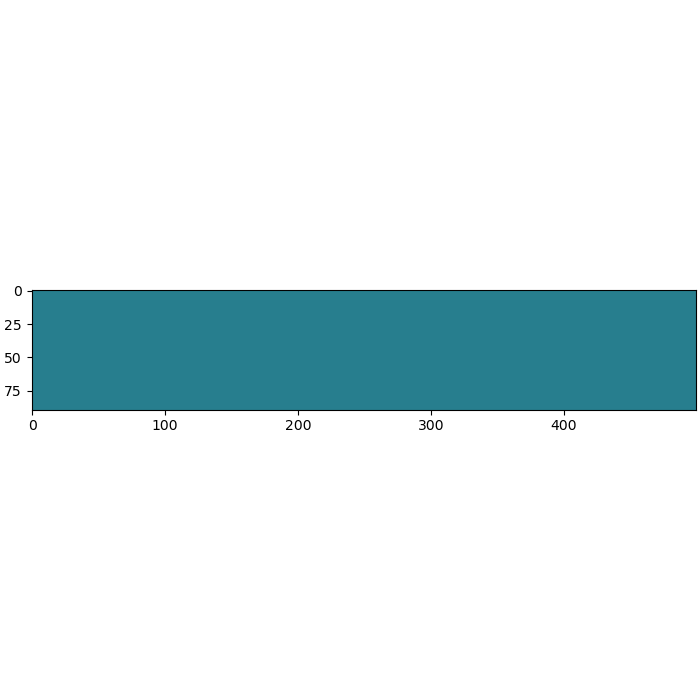

In [238]:
cimshow(data["i2d_diff"])

Text(0.5, 0, 'q')

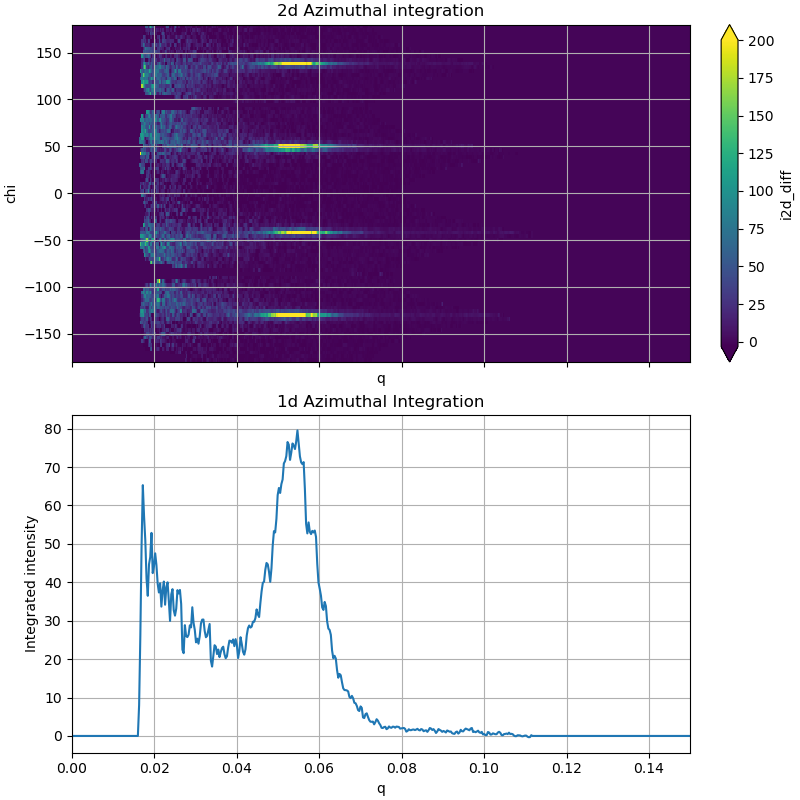

In [242]:
# Plot 2d and 1d azimuthal integration to estimate the relevant chi and q range
# which image to show?
idx = 21

# Select chi-range
# Which chi-mode? ("all","other")
chi_mode = "other"

# Select chi-range
if chi_mode == "all":
    sel_chi = (data.chi <= 180) * (data.chi >= -180)
elif chi_mode == "other":
    sel_chi = (
        (data.chi <= 145) * (data.chi >= 130)
        + (data.chi <= 60) * (data.chi >= 40)
        + (data.chi <= -35) * (data.chi >= -50)
        + (data.chi <= -120) * (data.chi >= -140)
    )
data["i1d"] = data.i2d.where(sel_chi, drop=True).mean("chi")
data["i1d_diff"] = data.i2d_diff.where(sel_chi, drop=True).mean("chi")

# Plot
fig, ax = plt.subplots(
    2,
    1,
    figsize=(8, 8),
    sharex=True,
)
mi, ma = np.nanpercentile(data["i2d"][idx], [0.1, 99.9])
data["i2d_diff"][idx].plot.imshow(ax=ax[0], vmin=mi, vmax=ma)
ax[0].set_title(f"2d Azimuthal integration")
ax[0].grid()

# Plot 1d azimuthal integration to estimate the relevant q-range
ax[1].plot(data.q, data.i1d_diff[idx])
#ax[1].set_yscale("log")
ax[1].set_title("1d Azimuthal Integration")
ax[1].grid()
ax[1].set_ylabel("Integrated intensity")
ax[1].set_xlabel("q")

## Select relevant q-range

In [247]:
# Select relevant q-range for averaging
q0, q1 = 0.04, 0.10
#q0, q1 = 0, 0.1
binning = False
bins = []

# Get SAXS from q-range
sel = (data.q > q0) * (data.q < q1)

data["saxs"] = data.i1d.where(sel, drop=True).mean("q")
data["saxs_diff"] = data.i1d_diff.where(sel, drop=True).mean("q")

# Averaging of same scan axis values or binning
if binning is True:
    # Execute binning
    data_bin = data.groupby_bins(key, bins).mean()

    # Rename binned values, drop intervals as those cannot be save in h5
    bin_scan_axis = scan_axis + "_bins"
    data_bin = data_bin.swap_dims({bin_scan_axis: key})
    data_bin = data_bin.drop(bin_scan_axis)
else:
    _, count = np.unique(data[key].values, return_counts=True)
    if np.any(count > 1):
        data_bin = data.groupby(key).mean()
    else:
        data_bin = data.swap_dims({"index": key})
        

Saving:/data/visitors/softimax/20250671/2026021708/process/SAXS_i1d_ImId_2019-2070_chrklose.png


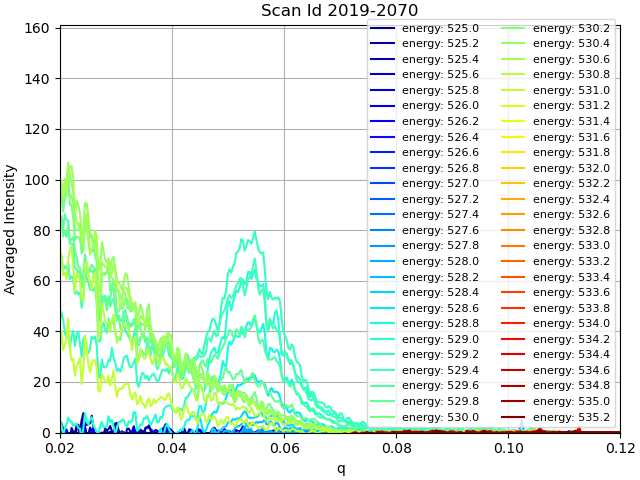

In [244]:
# Plot Averaged 1d Intensity over q for all different scan 
fig, ax = plt.subplots()
colors = plt.cm.jet(np.linspace(0,1,len(data_bin[key])))

for i, i1dchi in enumerate(data_bin["i1d_diff"].values):
    ax.plot(data_bin["q"],i1dchi,label="%s: %.1f"%(key,data_bin[key][i]),color = colors[i])
    
ax.grid()
ax.legend(ncol = 2,fontsize = 8)
ax.set_xlabel("q")
ax.set_ylabel("Averaged Intensity")
#ax.set_yscale("log")
ax.set_xlim([q0,q1])
ax.set_ylim([0, 1.1*data_bin["i1d_diff"].max().values])

## Title and fname
if len(im_ids) > 1:
    ax.set_title("Scan Id %s-%s" % (im_ids[0], im_ids[-1]))
    fname = "SAXS_i1d_ImId_%04d-%04d_%s.png" % (im_ids[0], im_ids[-1], USER)
else:
    ax.set_title("Scan Id %d" % (im_ids[0]))
    fname = "SAXS_i1d_ImId_%04d_%s.png" % (im_ids[0], USER)

fname = join(folder_general, fname)
print("Saving:%s" % fname)
plt.savefig(fname)

# Plotting

Saving:/data/visitors/softimax/20250671/2026021708/process/SAXS_ImId_2019-2070_chrklose.png


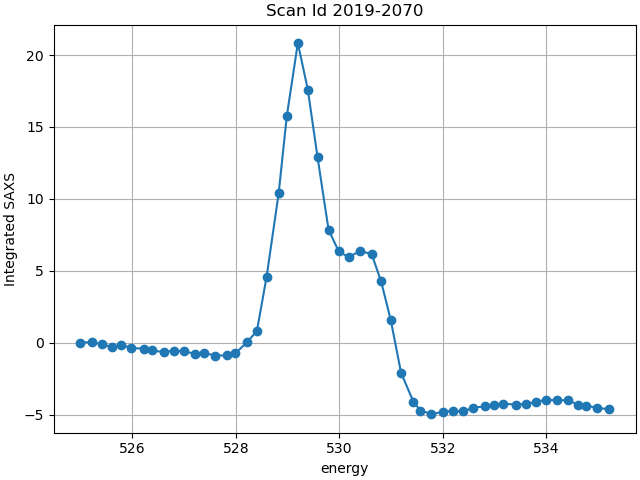

In [248]:
# Plot Intensity of SAXS Pattern
fig, ax = plt.subplots()
ax.plot(data_bin[key].values, data_bin["saxs_diff"].values,"o-")
ax.grid()
ax.set_xlabel(key)
ax.set_ylabel("Integrated SAXS")

## Title and fname
if len(im_ids) > 1:
    ax.set_title("Scan Id %s-%s" % (im_ids[0], im_ids[-1]))
    fname = "SAXS_ImId_%04d-%04d_%s.png" % (im_ids[0], im_ids[-1], USER)
else:
    ax.set_title("Scan Id %d" % (im_ids[0]))
    fname = "SAXS_ImId_%04d_%s.png" % (im_ids[0], USER)

fname = join(folder_general, fname)
print("Saving:%s" % fname)
plt.savefig(fname)

# Export scan as gif

## Select roi of images for plotting

How to use:
1. Zoom into the image and adjust your FOV until you are satisfied.
2. Save the axes coordinates.

interactive(children=(FloatRangeSlider(value=(-128.46047208726634, 170.82565873652968), description='contrast'…

interactive(children=(IntSlider(value=0, description='nr', max=51), Output()), _dom_classes=('widget-interact'…

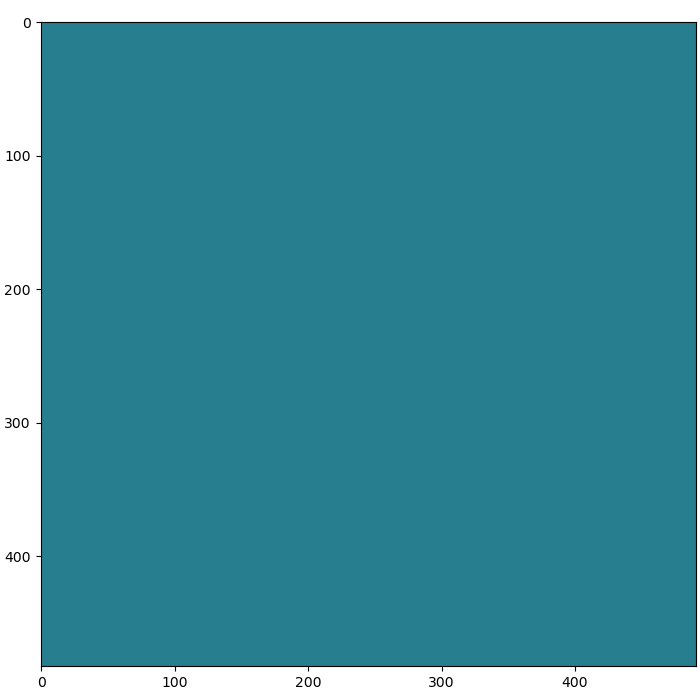

In [251]:
fig, ax = cimshow(data_bin["diffs"].values)

In [252]:
# Takes start and end of x and y axis
roi = interactive.axis_to_roi(ax)
print(f"Image registration roi:", roi)

Image registration roi: (slice(0, 482, None), slice(0, 490, None))


## Plotting

In [253]:
# Plot qrange
q0_plot, q1_plot = 0.02, 0.15

# Setup gif
folder_gif = helper.create_folder(join(folder_general, "ImId_%05d" % im_id))
variable_images_1d = []

# Find global max and min all images
allmin, allmax = np.nanpercentile(data_bin["i2d_diff"].values, [0.1, 100])
allImin = data_bin.i1d_diff.where(sel, drop=True).min()
allImax = data_bin.i1d_diff.where(sel, drop=True).max()

#if allImin <0.01:
#    allImin = 0.1
#if allmin <0.1:
#    allmin = 0.01

# Loop over images
for i in tqdm(range(len(data_bin[key].values))):
    # Plot for averaged image
    fig = plt.figure(figsize=(6, 10))
    gs1 = gridspec.GridSpec(
        4,
        1,
        figure=fig,
        left=0.2,
        bottom=0.05,
        right=0.975,
        top=1.1,
        wspace=0,
        hspace=0,
        height_ratios=[6, 1, 2, 1],
    )

    # Plot image roi
    ax0 = fig.add_subplot(gs1[0])
    tmp = data_bin["diffs"][i].values[roi]
    #tmp[tmp<allmin] = allmin
    #m = ax0.imshow(data_bin["diffs"][i].values[roi], norm = LogNorm(vmin = allImin, vmax=allImax))
    m = ax0.imshow(data_bin["diffs"][i].values[roi], vmin = allImin, vmax=allImax)
    plt.colorbar(m, ax=ax0, pad=0.045, location="bottom")

    # Plot 1d azimuthal integration
    ax1 = fig.add_subplot(gs1[1])
    tmp = data_bin.i1d_diff[i]
    ax1.plot(data_bin.q, tmp)
    ax1.set_xlabel("q")
    ax1.set_ylabel("Mean Intensity")
    ax1.set_xlim([q0_plot, q1_plot])
    ax1.set_ylim([allImin, allImax])
    #ax1.set_yscale("log")
    ax1.grid()

    # Contor plot
    ax2 = fig.add_subplot(gs1[2])
    vmin, vmax = np.nanpercentile(data_bin["i1d_diff"], [1, 99.9])
    data_bin["i1d_diff"].plot.contourf(
        x=key,
        y="q",
        ax=ax2,
        cmap="viridis",
        add_colorbar=False,
        vmin=vmin,
        vmax=vmax,
        levels=200,
        ylim = [q0_plot,q1_plot]
    )
    ax2.vlines(data_bin[key].values[i], q0, q1,'r')
    ax2.hlines(q0, data_bin[key].min(),data_bin[key].max(),'w',linestyles='dashed')
    ax2.hlines(q1, data_bin[key].min(),data_bin[key].max(),'w',linestyles='dashed')

    # Plot SAXS Intensity
    ax3 = fig.add_subplot(gs1[3])
    ax3.plot(data_bin[key].values, data_bin["saxs_diff"].values)
    ax3.scatter(data_bin[key].values[i], data_bin["saxs_diff"].values[i], 20, color="r")
    ax3.set_xlabel(key)
    ax3.set_ylabel("Mean intensity")
    ax3.grid()
    ax3.set_xlim(data_bin[key].min(),data_bin[key].max())

    # Title and fname
    ax0.set_title(
        f"%04d - %04d %s = %s"
        % (im_ids[0], im_ids[-1], key, np.round(data_bin[key].values[i], 3))
    )
    fname = "SAXS_ImId_%04d_%04d_%03d_%s.png" % (im_ids[0], im_ids[-1], i, USER)

    # Save
    fname = path.join(folder_gif, fname)
    variable_images_1d.append(fname)
    plt.savefig(fname)
    plt.close()

# Create gif for 1d AI
if len(im_ids) > 1:
    fname = f"SAXS_ImId_%04d_%04d_%s.gif" % (im_ids[0], im_ids[-1], USER)
else:
    fname = f"SAXS_ImId_%04d_%s.gif" % (im_ids[0], USER)

gif_path = path.join(folder_general, fname)
print("Saving gif:%s" % gif_path)
helper.create_gif(variable_images_1d,gif_path,fps=4)
print("Done!")

  0%|          | 0/52 [00:00<?, ?it/s]

Saving gif:/data/visitors/softimax/20250671/2026021708/process/SAXS_ImId_2019_2070_chrklose.gif
Done!


In [201]:
# Drop images
data_bin_save = data_bin.drop_vars(["images"])

# Save log
folder = join(folder_general, "Logs")
helper.create_folder(folder)
fname = join(folder, "SAXS_Log_ImId_%04d_%s.nc" % (im_id, USER))

print(f"Saving:", fname)
data_bin_save.to_netcdf(fname)

Saving: /data/visitors/softimax/20250671/2026021708/process/Logs/SAXS_Log_ImId_2009_chrklose.nc
